In [44]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [45]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [46]:
# 1. Load dataset

df = pd.read_csv('/content/used_car_price_dataset_extended.csv')

In [47]:
df.shape

(10000, 12)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
# Fill numerical NaNs with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)  # assign back instead of inplace

# Fill categorical NaNs with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)  # assign back instead of inplace


In [50]:
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,Full,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,Full,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [51]:

# 5. Feature Engineering
current_year = datetime.datetime.now().year
if 'year' in df.columns:
    df['car_age'] = current_year - df['year']
    df.drop('year', axis=1, inplace=True)

# Optional: price_per_mileage
if 'mileage' in df.columns:
    df['price_per_mileage'] = df['price_usd'] / (df['mileage'] + 1)  # avoid division by zero


In [52]:
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,Full,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,Full,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [53]:
# 6. Separate features and target
target = 'price_usd'
X = df.drop(target, axis=1)
y = df[target]

In [54]:
# 7. Target Encoding for high-cardinality categorical features
high_card_cols = [col for col in X.select_dtypes(include=['object']).columns if X[col].nunique() > 10]
low_card_cols = [col for col in X.select_dtypes(include=['object']).columns if col not in high_card_cols]


In [55]:
# Target Encoding
if high_card_cols:
    te = TargetEncoder(cols=high_card_cols)
    X[high_card_cols] = te.fit_transform(X[high_card_cols], y)

# One-hot encode low-cardinality categorical columns
X = pd.get_dummies(X, columns=low_card_cols, drop_first=True)


In [56]:
# 8. Scale numeric features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

In [57]:
X.columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count',
       'accidents_reported', 'fuel_type_Electric', 'fuel_type_Petrol',
       'brand_Chevrolet', 'brand_Ford', 'brand_Honda', 'brand_Hyundai',
       'brand_Kia', 'brand_Nissan', 'brand_Tesla', 'brand_Toyota',
       'brand_Volkswagen', 'transmission_Manual', 'color_Blue', 'color_Gray',
       'color_Red', 'color_Silver', 'color_White', 'service_history_Partial',
       'insurance_valid_Yes'],
      dtype='object')

In [58]:
# 6. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [59]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model
input_dim = X_train.shape[1]
model = Sequential([
    Dense(256, input_dim=input_dim, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
# 11. EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 12. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 59172996.0000 - mae: 7158.3096 - val_loss: 60624436.0000 - val_mae: 7290.2739
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 58436852.0000 - mae: 7105.6157 - val_loss: 58022824.0000 - val_mae: 7118.1650
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 53784908.0000 - mae: 6793.0601 - val_loss: 45917936.0000 - val_mae: 6270.6387
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 38773964.0000 - mae: 5650.0464 - val_loss: 17832386.0000 - val_mae: 3673.4573
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 12102599.0000 - mae: 2828.4641 - val_loss: 3977713.2500 - val_mae: 1609.0192
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4286050.0000 - mae: 1659.8500 - val_loss: 3333250.0000 - val_mae: 1450.7300
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 3512622.0000 - mae: 1489.5002 - val_loss: 2957585.2500 - val_mae: 1367.6317
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 13. Evaluate
y_pred = model.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 799.81
MSE: 1004781.58
RMSE: 1002.39
R²: 0.8737


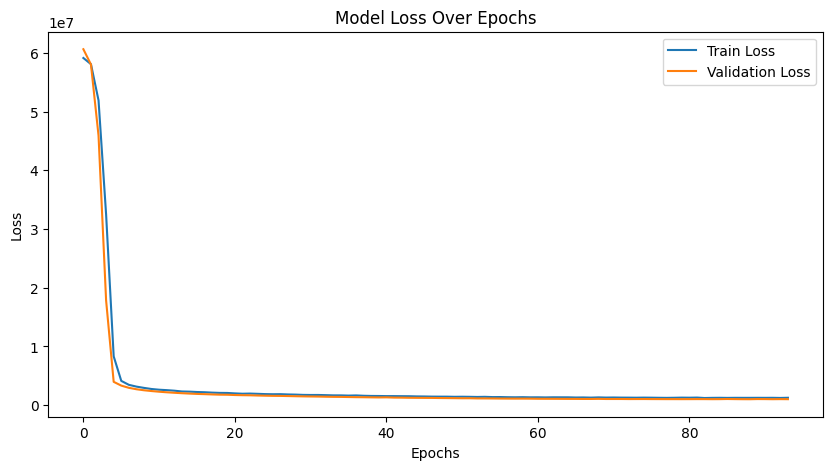

In [62]:
# 1. Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

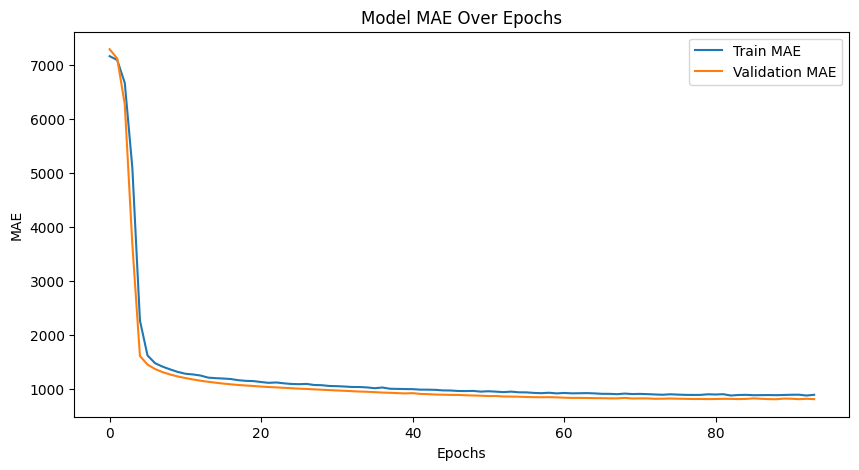

In [63]:
# 2. Training & Validation MAE
plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

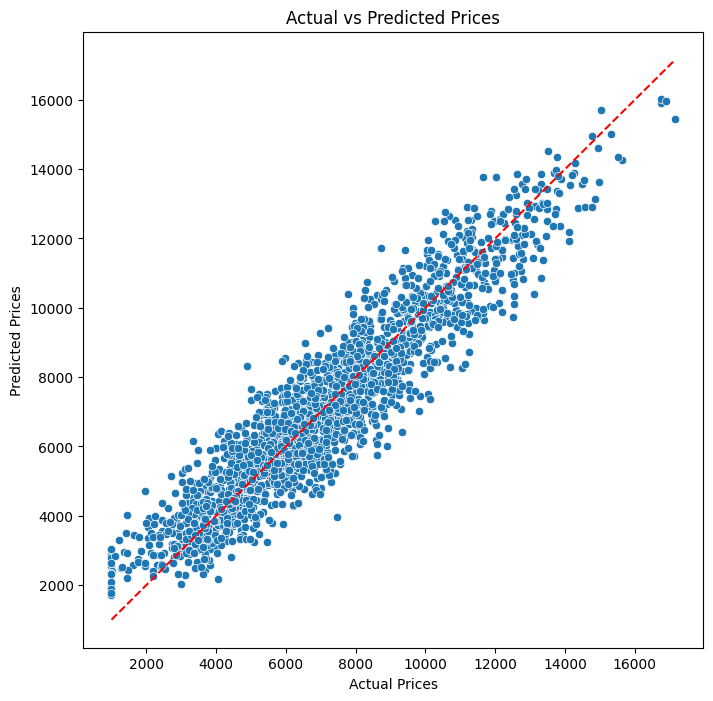

In [64]:
# 3. Predicted vs Actual Prices
plt.figure(figsize=(8,8))
sns.scatterplot(x=y_test, y=y_pred.flatten())
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.show()


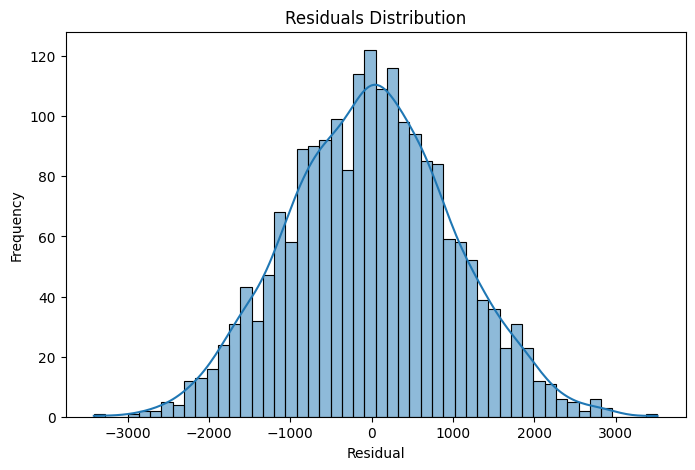

In [65]:
# 4. Residuals Plot
residuals = y_test - y_pred.flatten()
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()